# SEC Baseball scoring rates from 2000-2026

In [1]:
# create a data frame; note row index starts at zero
# note: the filename is relative to ~/work

import pandas as pd
df = pd.read_csv("secbaseball/secbaseball.tsv", sep="\t")
df.head()

,team,year,w,l,t,pf,pa
0,Alabama,2000,19,16,0,276,239
1,Alabama,2001,15,15,0,236,165
2,Alabama,2002,28,11,0,267,161
3,Alabama,2003,18,16,0,213,192
4,Alabama,2004,10,21,0,138,168


In [2]:
# create some derived columns

df["n"] = df["w"] + df["l"] + df["t"]
df["pct"] = ((df["w"] + 0.5 * df["t"]) / df["n"])
df["pfpg"] = (df["pf"] / df["n"])
df["papg"] = (df["pa"] / df["n"])
df["totalpg"] = (df["pfpg"] + df["papg"])

df.head()

,team,year,w,l,t,pf,pa,n,pct,pfpg,papg,totalpg
0,Alabama,2000,19,16,0,276,239,35,0.542857,7.885714,6.828571,14.714286
1,Alabama,2001,15,15,0,236,165,30,0.500000,7.866667,5.500000,13.366667
2,Alabama,2002,28,11,0,267,161,39,0.717949,6.846154,4.128205,10.974359
3,Alabama,2003,18,16,0,213,192,34,0.529412,6.264706,5.647059,11.911765
4,Alabama,2004,10,21,0,138,168,31,0.322581,4.451613,5.419355,9.870968


In [3]:
# query/filter rows 
# for display, you can specify column formats

df.query("year == 2026").style.format({
    "pct": "{:.3f}",
    "pfpg": "{:.2f}",
    "papg": "{:.2f}",
    "totalpg": "{:.2f}",
})

,team,year,w,l,t,pf,pa,n,pct,pfpg,papg,totalpg
25,Alabama,2026,18,15,0,167,192,33,0.545,5.06,5.82,10.88
51,Arkansas,2026,20,14,0,223,210,34,0.588,6.56,6.18,12.74
77,Auburn,2026,19,16,0,200,137,35,0.543,5.71,3.91,9.63
103,Florida,2026,20,13,0,218,162,33,0.606,6.61,4.91,11.52
129,Georgia,2026,30,9,0,292,222,39,0.769,7.49,5.69,13.18
155,Kentucky,2026,13,18,0,186,211,31,0.419,6.00,6.81,12.81
181,LSU,2026,10,22,0,203,236,32,0.312,6.34,7.38,13.72
207,Mississippi,2026,17,17,0,182,199,34,0.500,5.35,5.85,11.21
233,Mississippi St,2026,18,17,0,240,203,35,0.514,6.86,5.80,12.66
246,Missouri,2026,7,25,0,126,228,32,0.219,3.94,7.12,11.06


In [4]:
yearly_df = df.groupby("year").agg({
        "w": "sum",
        "l": "sum",
        "t": "sum",
        "n": "sum",
        "pf": "sum",
        "pa": "sum"
    })
yearly_df["runs_per_game"] = (yearly_df["pf"] + yearly_df["pa"]) / yearly_df["n"]
yearly_df.style.format({
    "runs_per_game": "{:.2f}",
})

# note: indexed by the year

,w,l,t,n,pf,pa,runs_per_game
year,,,,,,,
2000,188,188,0,376,2643,2643,14.06
2001,196,196,0,392,2444,2444,12.47
2002,197,197,0,394,2464,2464,12.51
2003,193,193,2,388,2066,2066,10.65
2004,196,196,0,392,2105,2105,10.74
2005,194,194,0,388,2032,2032,10.47
2006,197,197,0,394,2383,2383,12.10
2007,193,193,2,388,2312,2312,11.92
2008,193,193,2,388,2413,2413,12.44


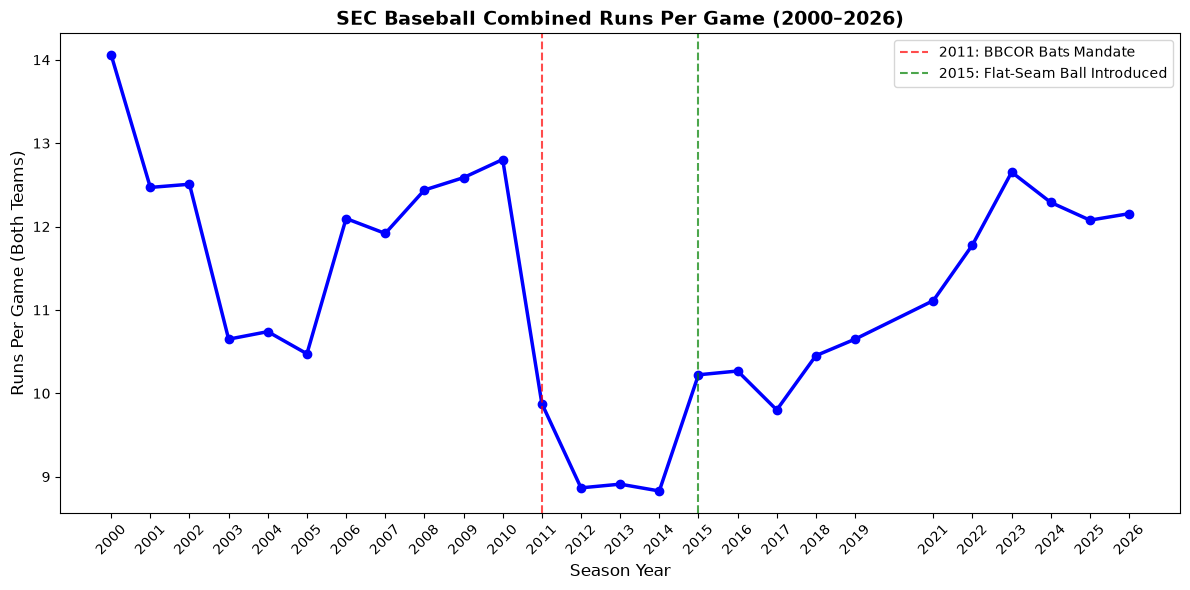

In [5]:
# Plot the time series

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(yearly_df.index, yearly_df["runs_per_game"], marker="o", linewidth=2.5, color="blue")

# Annotate structural regulatory shocks
plt.axvline(x=2011, color="red", linestyle="--", alpha=0.7, label="2011: BBCOR Bats Mandate")
plt.axvline(x=2015, color="green", linestyle="--", alpha=0.7, label="2015: Flat-Seam Ball Introduced")

plt.title("SEC Baseball Combined Runs Per Game (2000–2026)", fontsize=14, fontweight="bold")
plt.xlabel("Season Year", fontsize=12)
plt.ylabel("Runs Per Game (Both Teams)", fontsize=12)
plt.xticks(yearly_df.index, rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()